# ⚡️ Baseline Forecast: Linear Regression

**Linear Regression** models the target as a **weighted sum of features** plus an intercept, choosing weights that minimize **squared error**. It’s fast, interpretable, and a great **baseline** when effects are roughly **linear** and errors are homoscedastic/independent.
**Strengths:** simple, explainable coefficients, quick to train.
**Watch-outs:** sensitive to **outliers**, **multicollinearity**, and **nonlinear** patterns; extrapolates linearly.
**Key knobs:** add **regularization** if needed—**Ridge** (L2) for stability, **Lasso** (L1) for sparsity, **Elastic Net** for a mix.


This guided tutorial turns a **plain Linear Regression** into a solid, interpretable **energy baseline**.

**What you'll learn**
- 📥 Data loading & time indexing  
- 🧹 Handling missing values  
- 🧰 Feature engineering (lags, rolling, calendar)  
- 🧪 Proper time-aware split  
- 🤖 **Linear Regression** fit & predict  
- 📏 Metrics (MAE, RMSE, MAPE) + quick plots  
- 🧐 Model interpretation (coefficients, signs, units)  

> Use this LR baseline as a **yardstick**. If fancier models (trees, SARIMA, Prophet, DL) cannot beat it, revisit features, splits, and leakage.

## 🛠️ Setup & Imports

Lean stack: **pandas**, **numpy**, **matplotlib/seaborn** for EDA/plots;  
**scikit‑learn** for LinearRegression and metrics. Keep versions pinned for reproducibility.

## 🤖 Linear Model: Fit & Predict

Fit a **LinearRegression** (optionally **Ridge/Lasso** for regularization).  
Check assumptions lightly: linearity, multicollinearity, scale. Standardize if mixing units.

## 📏 Evaluation Metrics

Report:  
- **MAE** (robust, unit‑scale)  
- **RMSE** (punishes big misses)  
- **MAPE** (%; beware near‑zeros)  
- **R²** (variance explained; interpret with care in time series)

## 📊 Plots & Residual Diagnostics

- Actual vs Predicted  
- Residual histogram / KDE  
- Residuals over time (look for drift/seasonality)  
- Error by **hour/DoW** to spot pattern bias

In [5]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

# Read datasets

## 📥 Load the Data

Read time‑series data, parse **datetime**, and check units (e.g., **kWh**).  
Document the source window (start/end) to make experiments comparable.

## 🕒 Time Index & Frequency

Set a clean **DatetimeIndex** with the right frequency (hourly/daily).  
Align timezones and ensure no duplicates/overlaps (DST!).

In [6]:
dataset = pd.read_csv('data/kaggle_competition_dataset.csv',
            parse_dates=['time'])
dataset.set_index('time', inplace=True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8592 entries, 2021-09-01 00:00:00 to 2022-08-24 23:00:00
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temp         8592 non-null   float64
 1   dwpt         8592 non-null   float64
 2   rhum         8592 non-null   float64
 3   prcp         2159 non-null   float64
 4   snow         119 non-null    float64
 5   wdir         8592 non-null   float64
 6   wspd         8592 non-null   float64
 7   wpgt         8592 non-null   float64
 8   pres         8592 non-null   float64
 9   coco         8396 non-null   float64
 10  el_price     8592 non-null   float64
 11  consumption  8592 non-null   float64
dtypes: float64(12)
memory usage: 872.6 KB


# Features


In [7]:
demand = dataset[['consumption']]
demand = demand.rename(columns = {'consumption':'demand'})
demand.head()

,demand
time,
2021-09-01 00:00:00,0.577
2021-09-01 01:00:00,0.594
2021-09-01 02:00:00,0.685
2021-09-01 03:00:00,1.016
2021-09-01 04:00:00,0.677


## 🧰 Feature Engineering

Practical features that LR loves:  
- 🔁 **Lags** (1, 24, 24×7) to capture autocorrelation/weekly pattern  
- 📈 **Rolling stats** (mean/min/max/std) for local context  
- 📆 **Calendar** (hour, DoW, month, holidays)  
- 🌡️ **Externals** (temperature, humidity) if available

> Keep features **leakage‑safe** (use only past information when predicting).

In [8]:
time_data = demand.copy()
time_data['ts'] = pd.to_datetime(time_data.index.values, dayfirst=True)
time_data = time_data.drop(columns=['demand'])
time_data['wd'] = time_data['ts'].dt.dayofweek
time_data['h'] = time_data['ts'].dt.hour

time_data["h_sin"] = np.sin(2 * np.pi * time_data["h"] / 24)
time_data["h_cos"] = np.cos(2 * np.pi * time_data["h"] / 24)

time_data["dow_sin"] = np.sin(2 * np.pi * time_data["wd"] / 7)
time_data["dow_cos"] = np.cos(2 * np.pi * time_data["wd"] / 7)


time_data

,ts,wd,h,h_sin,h_cos,dow_sin,dow_cos
time,,,,,,,
2021-09-01 00:00:00,2021-09-01 00:00:00,2,0,0.000000,1.000000,0.974928,-0.222521
2021-09-01 01:00:00,2021-09-01 01:00:00,2,1,0.258819,0.965926,0.974928,-0.222521
2021-09-01 02:00:00,2021-09-01 02:00:00,2,2,0.500000,0.866025,0.974928,-0.222521
2021-09-01 03:00:00,2021-09-01 03:00:00,2,3,0.707107,0.707107,0.974928,-0.222521
2021-09-01 04:00:00,2021-09-01 04:00:00,2,4,0.866025,0.500000,0.974928,-0.222521
...,...,...,...,...,...,...,...
2022-08-24 19:00:00,2022-08-24 19:00:00,2,19,-0.965926,0.258819,0.974928,-0.222521
2022-08-24 20:00:00,2022-08-24 20:00:00,2,20,-0.866025,0.500000,0.974928,-0.222521
2022-08-24 21:00:00,2022-08-24 21:00:00,2,21,-0.707107,0.707107,0.974928,-0.222521


In [9]:
lag7d = demand[['demand']].shift(24*7)
lag7d = lag7d.rename(columns = {'demand':'lag7'})

In [10]:
lag1d = demand[['demand']].shift(24)
lag1d = lag1d.rename(columns = {'demand':'lag1'})

In [11]:
temperature = dataset[['temp']]
price = dataset[['el_price']]

In [12]:
features = lag7d.copy()
features = features.join(lag1d)
features = features.join(temperature)
features = features.join(time_data)
features = features.join(price)
#features.tail()

dataset = demand.join(features)
dataset.tail()

,demand,lag7,lag1,temp,ts,wd,h,h_sin,h_cos,dow_sin,dow_cos,el_price
time,,,,,,,,,,,,
2022-08-24 19:00:00,0.678,0.897,0.379,27.1,2022-08-24 19:00:00,2,19,-0.965926,0.258819,0.974928,-0.222521,0.53494
2022-08-24 20:00:00,0.457,2.796,0.609,25.1,2022-08-24 20:00:00,2,20,-0.866025,0.500000,0.974928,-0.222521,0.49990
2022-08-24 21:00:00,0.500,0.733,1.572,24.9,2022-08-24 21:00:00,2,21,-0.707107,0.707107,0.974928,-0.222521,0.43149
2022-08-24 22:00:00,2.321,1.490,1.016,22.1,2022-08-24 22:00:00,2,22,-0.500000,0.866025,0.974928,-0.222521,0.55203
2022-08-24 23:00:00,0.678,0.222,0.243,22.1,2022-08-24 23:00:00,2,23,-0.258819,0.965926,0.974928,-0.222521,0.43108


In [13]:
fs1 = ['lag7']
fs2 = ['lag7', 'lag1']
fs3 = ['lag7', 'lag1','temp']
fs4 = ['lag7', 'lag1','temp','h_sin','h_cos','dow_sin','dow_cos']
fs5 = ['temp', 'lag1','h_sin','h_cos','dow_sin','dow_cos']
fs6 = ['lag7','lag1', 'h_sin','h_cos','dow_sin','dow_cos']
fs7 = ['h_sin','h_cos','dow_sin','dow_cos']
fs8 = ['el_price','h_sin','h_cos','dow_sin','dow_cos']
fs9 = ['el_price','lag7','lag1','h_sin','h_cos','dow_sin','dow_cos']

fs = [fs1, fs2, fs3, fs4, fs5, fs6, fs7, fs8, fs9]

# Forecast

## 🔮 Make Predictions

Generate predictions on validation/test windows. Store them with the corresponding timestamps for plotting/metrics.

lag7
MAPE: 82.443 MAE: 0.390 RMSE: 0.499
lag7 lag1
MAPE: 77.469 MAE: 0.370 RMSE: 0.484
lag7 lag1 temp
MAPE: 79.015 MAE: 0.371 RMSE: 0.467
lag7 lag1 temp h_sin h_cos dow_sin dow_cos
MAPE: 73.292 MAE: 0.364 RMSE: 0.467
temp lag1 h_sin h_cos dow_sin dow_cos
MAPE: 75.606 MAE: 0.370 RMSE: 0.472
lag7 lag1 h_sin h_cos dow_sin dow_cos
MAPE: 67.211 MAE: 0.355 RMSE: 0.469
h_sin h_cos dow_sin dow_cos
MAPE: 70.808 MAE: 0.369 RMSE: 0.481
el_price h_sin h_cos dow_sin dow_cos
MAPE: 71.938 MAE: 0.372 RMSE: 0.482
el_price lag7 lag1 h_sin h_cos dow_sin dow_cos
MAPE: 68.404 MAE: 0.357 RMSE: 0.469


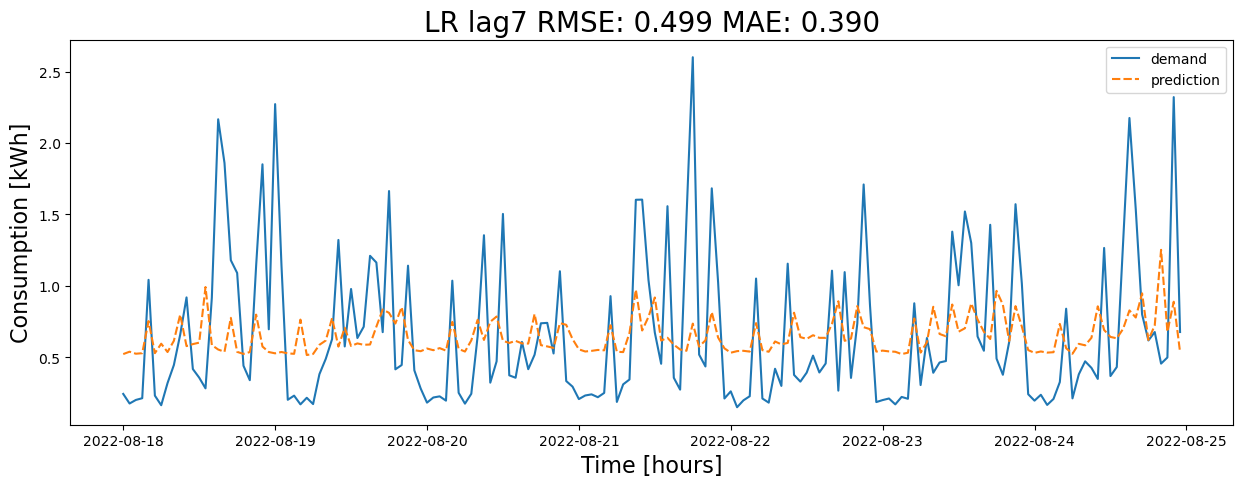

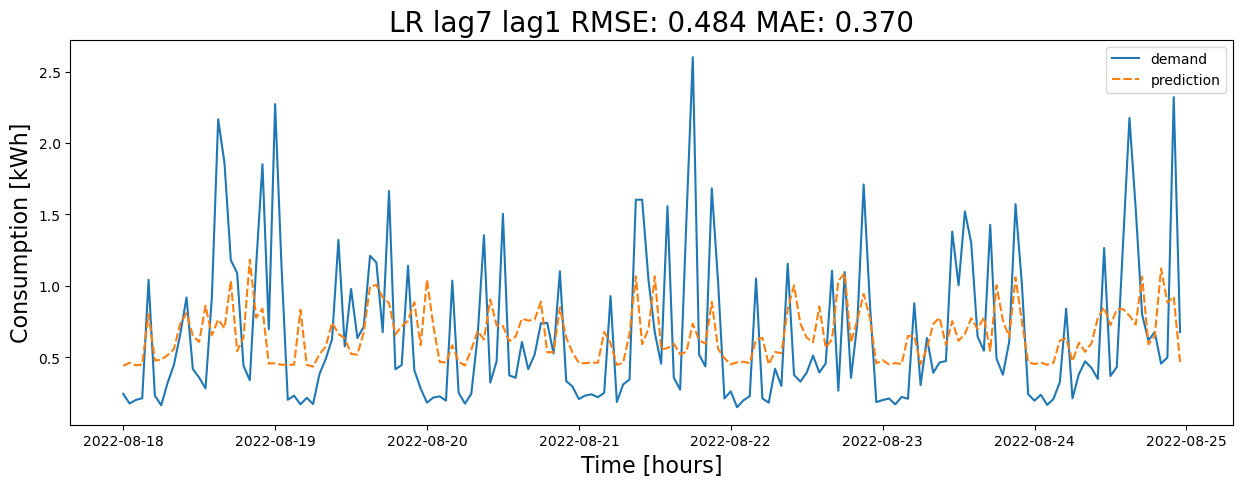

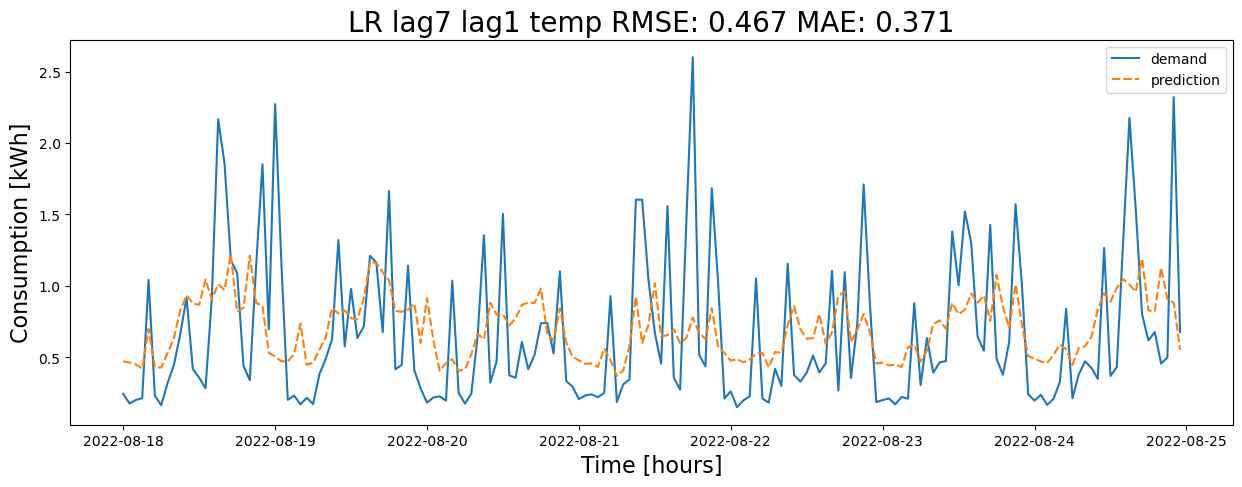

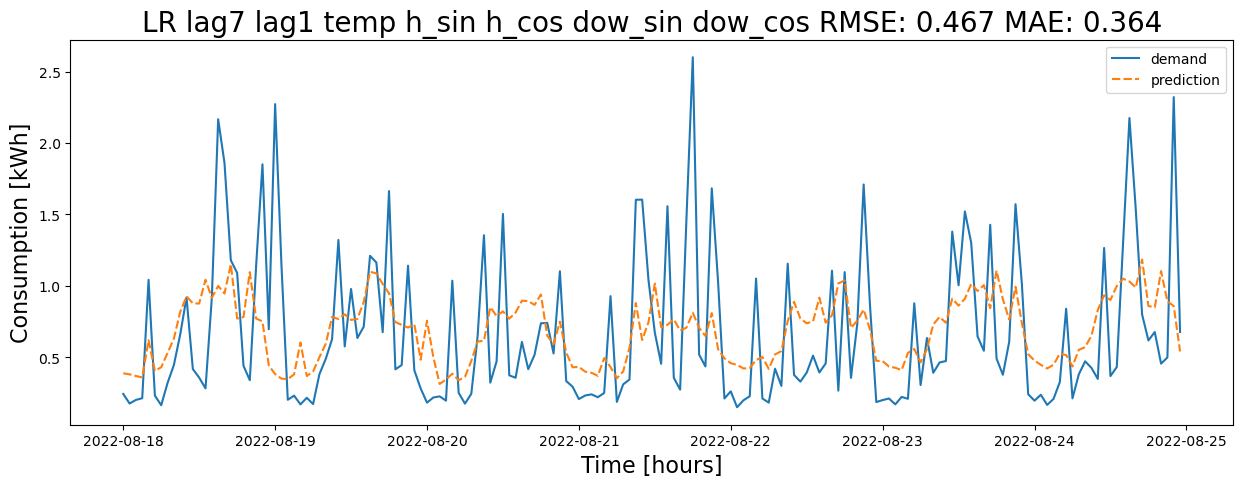

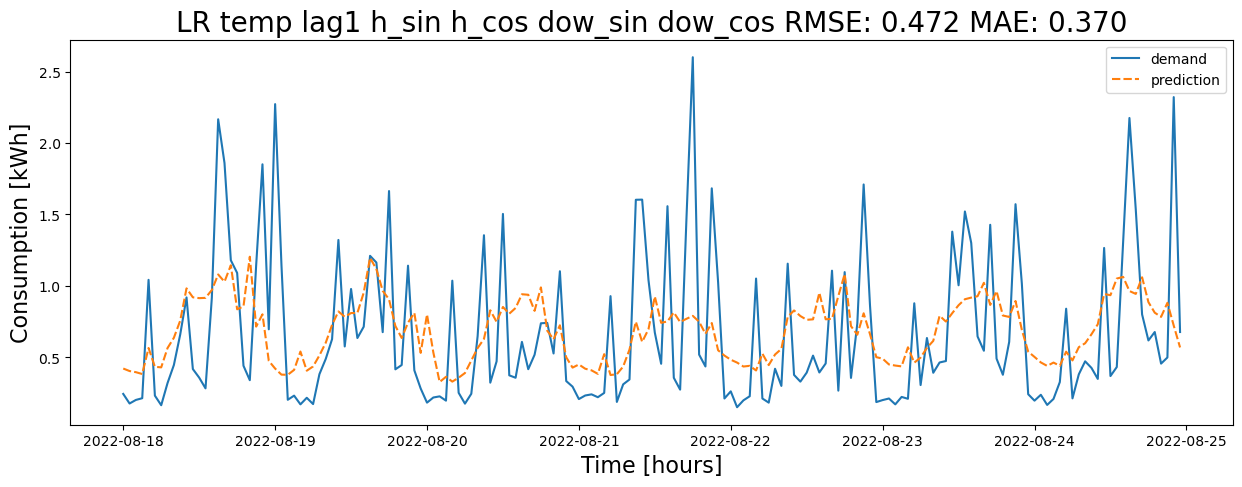

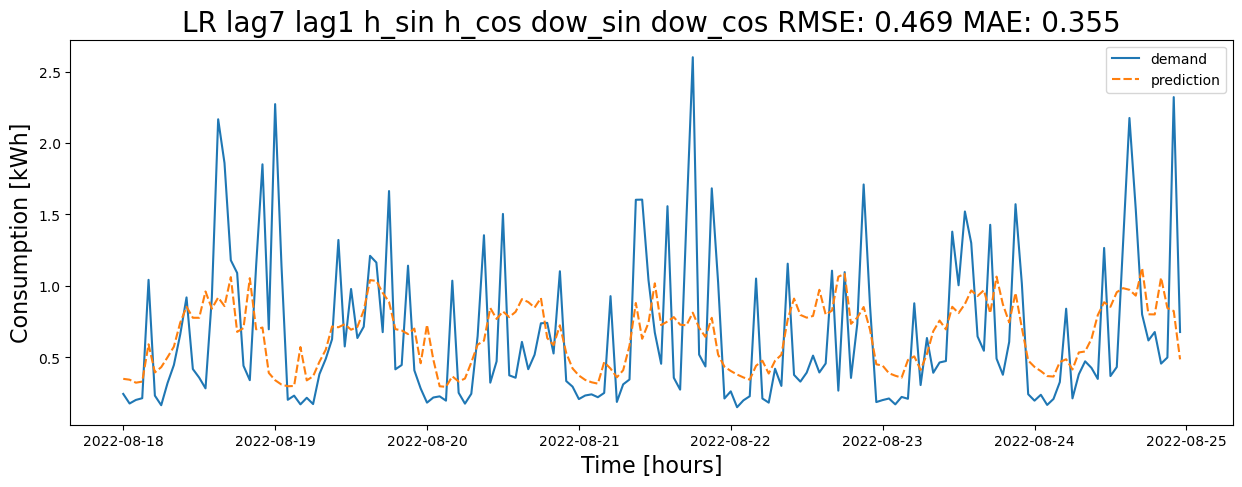

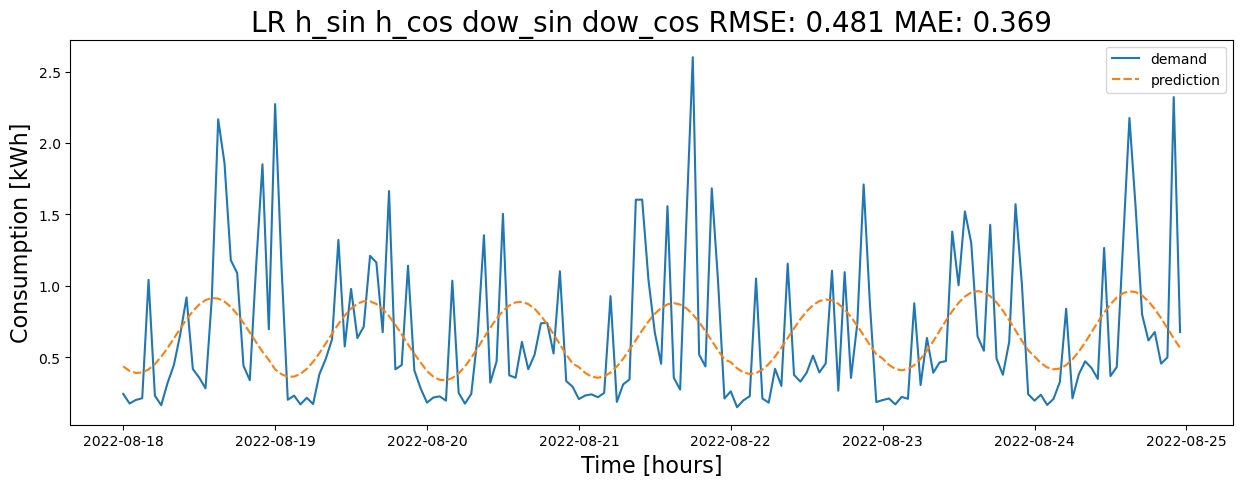

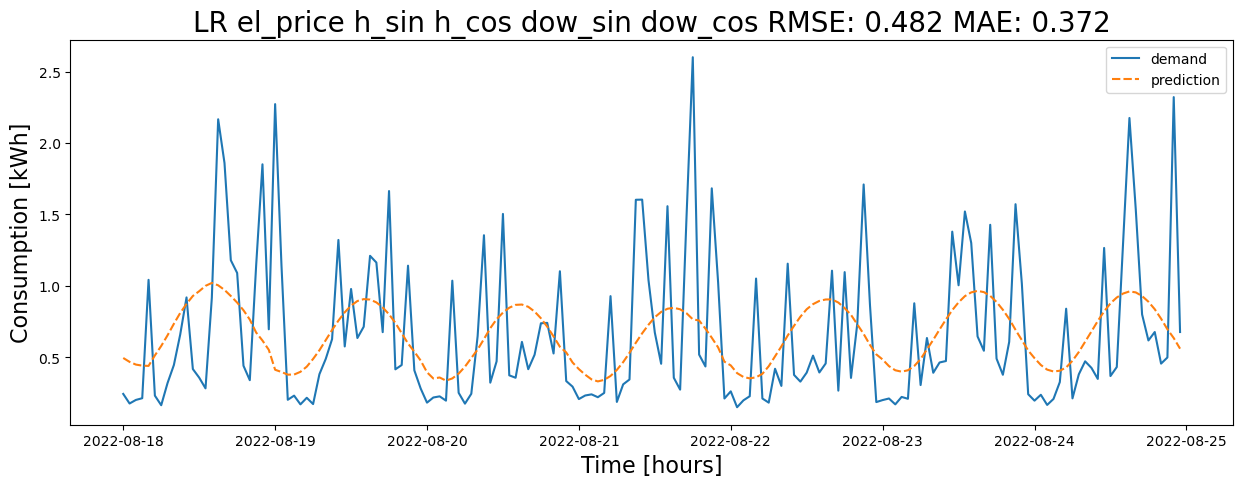

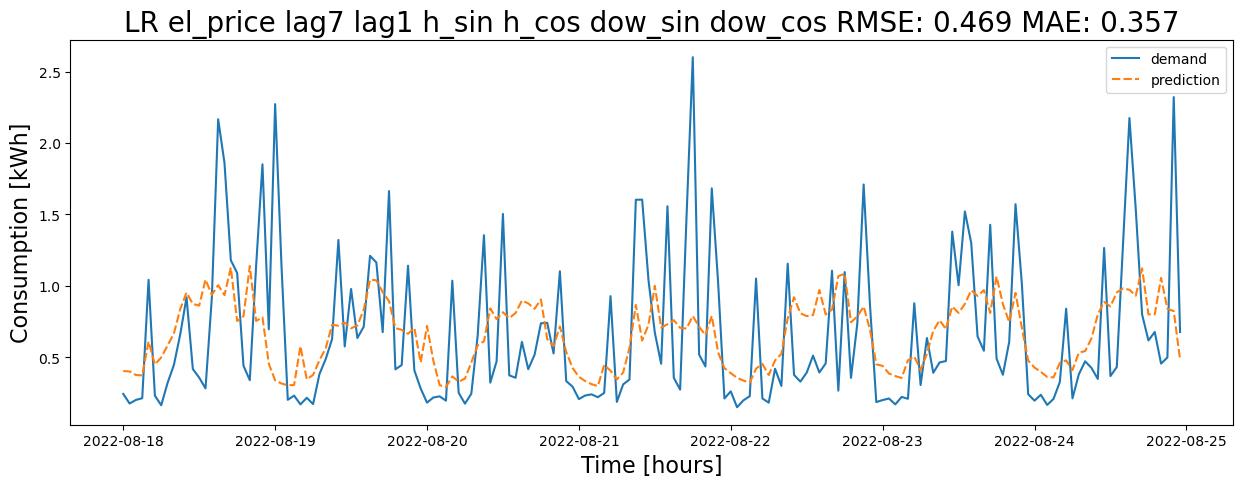

In [14]:
predict_days = 7
training_data_length =14
last_dataset_day = dataset.index.max().date()
prediction_start = pd.to_datetime(last_dataset_day - datetime.timedelta(days = predict_days-1))

#print(prediction_start)
#print(last_dataset_day)

def rolling_lr_forecast(ad_fs):
  actual_full = pd.DataFrame()
  forecast_full = pd.DataFrame()

  for d in range(0,predict_days):

    predict_for_start = pd.to_datetime(prediction_start + datetime.timedelta(days = d))
    predict_for_end = pd.to_datetime(predict_for_start + datetime.timedelta(days = 1))

    training_end = pd.to_datetime(predict_for_start - datetime.timedelta(days = 1))
    training_start = pd.to_datetime(training_end - datetime.timedelta(days = training_data_length))

    test_set = dataset[(dataset.index >= predict_for_start) &  (dataset.index < predict_for_end)]
    train_set = dataset[(dataset.index >= training_start) &  (dataset.index < training_end)]

    X_test = test_set[ad_fs]
    y_test = test_set[['demand']]

    X_train = train_set[ad_fs]
    y_train = train_set[['demand']]

    model = LinearRegression()
    model.fit(X_train,y_train)

    predictions =  pd.DataFrame(model.predict(X_test))
    predictions.set_index(y_test.index, inplace=True)
    predictions = predictions.rename(columns = {0:'prediction'})

    actual_full = pd.concat([actual_full, y_test])#, ignore_index=True)
    forecast_full = pd.concat([forecast_full, predictions])#, ignore_index=True)

##############################
  mapestring="MAPE: %.3f" % (mean_absolute_percentage_error(actual_full, forecast_full)*100)
  maestring="MAE: %.3f" % (mean_absolute_error(actual_full, forecast_full))
  rmsestring = "RMSE: %.3f" % (np.sqrt(mean_squared_error(actual_full, forecast_full)))


  plt.figure(figsize=(15,5))
  p = sns.lineplot(data = actual_full.join(forecast_full));
  plt.title("LR " + " ".join(ad_fs)+" "+rmsestring+" "+maestring, fontsize = 20)
  p.set_xlabel("Time [hours]", fontsize = 16);
  p.set_ylabel("Consumption [kWh]", fontsize = 16);
  #plt.show()

  print( " ".join(ad_fs))
  print(mapestring+" "+maestring+" "+rmsestring)

  #print(str(predict_for_start)+" "+ str(training_start)+" "+str(training_end))

for ad_fs in fs:
  rolling_lr_forecast(ad_fs)